# **Regresion Lineal: Costo de un incidente de Seguridad**

En este ejercicio se explican los fundamentos basicos de la regresion lineal aplicado a un caso de uso sencillo relacionado con la Ciberseguridad

### **Enunciado del ejercicio**

Predecir el costo de un incidente de seguridad en base al numero de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.

## 1.- Generacion del DataSet (conjunto de datos)

In [1]:
import numpy as np

x = 2 * np.random.rand(100,1)
y = 4 + 3 * x + np.random.randn(100,1)

print("La longitud del DataSet es:", len(x))

La longitud del DataSet es: 100


## 2.- Visualizacion del DataSet

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

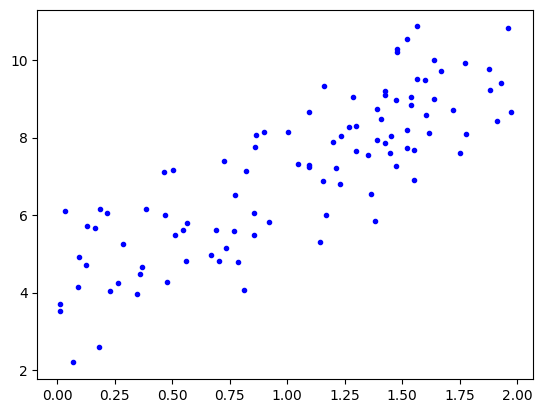

In [3]:
plt.plot(x,y, "b.")
plt.show()

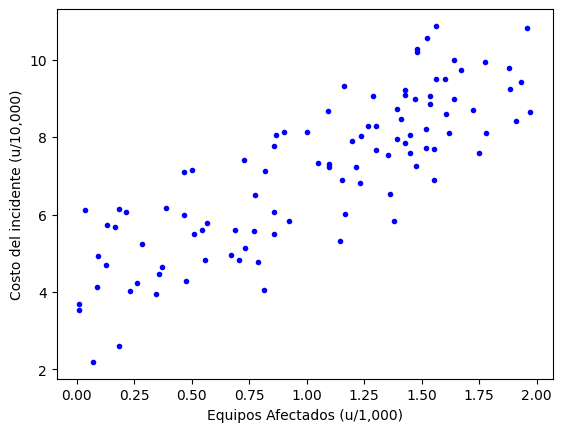

In [4]:
plt.plot(x,y, "b.")
plt.xlabel("Equipos Afectados (u/1,000)")
plt.ylabel("Costo del incidente (u/10,000)")
plt.show()

## 3.- Modificacion del DataSet

In [5]:
import pandas as pd

In [6]:
Data = {'No_Equipos_Afectados': x.flatten(),'Costo': y.flatten()}

In [7]:
df = pd.DataFrame(Data)
df.head(10)

,No_Equipos_Afectados,Costo
0,1.047669,7.321576
1,1.390854,7.950297
2,0.124943,4.699562
3,1.155216,6.892754
4,1.604180,8.596817
5,0.181813,2.596437
6,0.385570,6.167328
7,0.900023,8.135360
8,0.093532,4.919012
9,0.864637,8.063028


In [8]:
# Escalado del Numero de Equipos Afectados
df["No_Equipos_Afectados"] = df["No_Equipos_Afectados"] * 1000
df["No_Equipos_Afectados"] = df["No_Equipos_Afectados"].astype("int")
# Escalado del Costo
df["Costo"] = df["Costo"] * 10000
df["Costo"] = df["Costo"].astype("int")
df.head(10)

,No_Equipos_Afectados,Costo
0,1047,73215
1,1390,79502
2,124,46995
3,1155,68927
4,1604,85968
5,181,25964
6,385,61673
7,900,81353
8,93,49190
9,864,80630


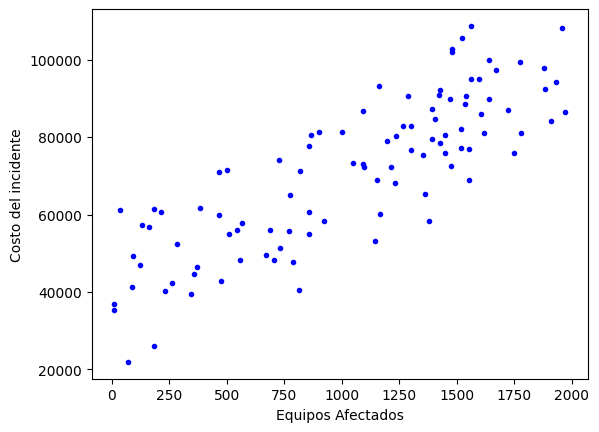

In [9]:
# Representacion grafica de los datos
plt.plot(df["No_Equipos_Afectados"], df["Costo"], "b.")
plt.xlabel("Equipos Afectados")
plt.ylabel("Costo del incidente")
plt.show()

## 4.- Construccion del Modelo

In [10]:
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
# Construccion del modelo y ajuste de la funcion de hipotesis 

lin_reg = LinearRegression()
lin_reg.fit(df["No_Equipos_Afectados"].values.reshape(-1,1), df["Costo"].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# Parametro theta 0
lin_reg.coef_

array([29.03476555])

In [14]:
# Parametro theta 1
lin_reg.intercept_

np.float64(40825.198674036525)

In [15]:
df.describe()

,No_Equipos_Afectados,Costo
count,100.000000,100.000000
mean,1038.710000,70983.900000
std,561.040273,19584.044928
min,11.000000,21946.000000
25%,554.500000,56120.750000
50%,1157.500000,73094.000000
75%,1488.500000,86107.000000
max,1972.000000,108700.000000


In [16]:
# Prediccion para el valor minimo y maximo del DataSet de entrenamiento
x_min_max = np.array([[df["No_Equipos_Afectados"].min()],[df["No_Equipos_Afectados"].max()]])
y_train_pred = lin_reg.predict(x_min_max)


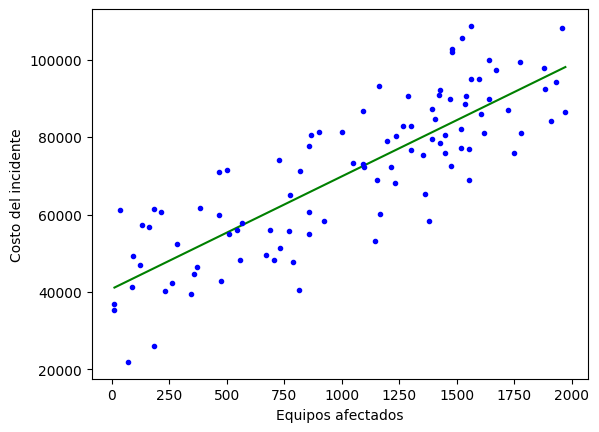

In [17]:
# Representacion grafica de la funcion de hipotesis
plt.plot(x_min_max, y_train_pred, "g-")
plt.plot(df["No_Equipos_Afectados"], df["Costo"], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del incidente")
plt.show()

## 5.- Prediccion de nuevos ejemplos 

In [22]:
x_new = np.array([[100]])
costo = lin_reg.predict(x_new)

print("El costo del incidente seria: $", int(costo[0]))

El costo del incidente seria: $ 43728


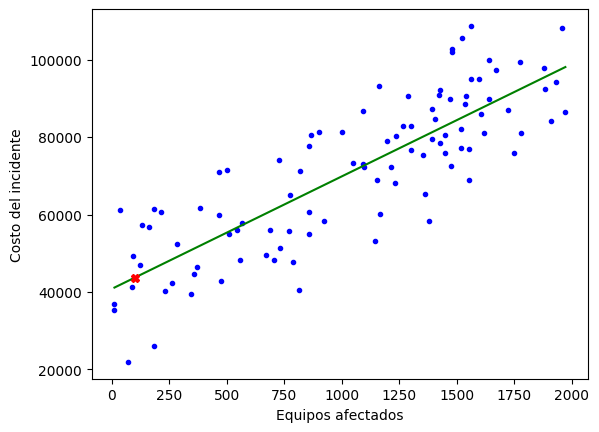

In [23]:
plt.plot(df["No_Equipos_Afectados"],df["Costo"], "b.")
plt.plot(x_min_max, y_train_pred, "g-")
plt.plot(x_new, costo, "rX")
plt.xlabel("Equipos afectados")
plt.ylabel("Costo del incidente")
plt.show()